In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df_summary = pd.read_csv("/kaggle/input/datasets/smid80/weatherww2/Summary of Weather.csv")
df_weather = pd.read_csv("/kaggle/input/datasets/smid80/weatherww2/Weather Station Locations.csv")

/tmp/ipykernel_16/2237268620.py:1: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_summary = pd.read_csv("/kaggle/input/datasets/smid80/weatherww2/Summary of Weather.csv")


In [3]:
df_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  object 
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-

In [4]:
df_summary.head()

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_summary.isnull().sum()

STA                 0
Date                0
Precip              0
WindGustSpd    118508
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
DR             118507
SPD            118508
MAX               474
MIN               468
MEA               498
SNF              1163
SND            113477
FT             119040
FB             119040
FTI            119040
ITH            119040
PGT            118515
TSHDSBRSGF      84803
SD3            119040
RHX            119040
RHN            119040
RVG            119040
WTE            119040
dtype: int64

In [6]:
missing_rates = df_summary.isnull().sum()/len(df_summary)*100
missing_rates.sort_values(ascending=True)

STA              0.000000
Date             0.000000
Precip           0.000000
MaxTemp          0.000000
MeanTemp         0.000000
MinTemp          0.000000
MO               0.000000
YR               0.000000
DA               0.000000
MIN              0.393145
MAX              0.398185
MEA              0.418347
Snowfall         0.976983
SNF              0.976983
PRCP             1.622984
PoorWeather     71.239079
TSHDSBRSGF      71.239079
SND             95.326781
DR              99.552251
WindGustSpd     99.553091
SPD             99.553091
PGT             99.558972
FT             100.000000
FB             100.000000
ITH            100.000000
FTI            100.000000
SD3            100.000000
RHX            100.000000
RHN            100.000000
RVG            100.000000
WTE            100.000000
dtype: float64

In [7]:
df_summary.dropna(thresh=len(df_summary) * 0.3, axis=1,inplace=True)

In [8]:
df_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       119040 non-null  int64  
 1   Date      119040 non-null  object 
 2   Precip    119040 non-null  object 
 3   MaxTemp   119040 non-null  float64
 4   MinTemp   119040 non-null  float64
 5   MeanTemp  119040 non-null  float64
 6   Snowfall  117877 non-null  object 
 7   YR        119040 non-null  int64  
 8   MO        119040 non-null  int64  
 9   DA        119040 non-null  int64  
 10  PRCP      117108 non-null  object 
 11  MAX       118566 non-null  float64
 12  MIN       118572 non-null  float64
 13  MEA       118542 non-null  float64
 14  SNF       117877 non-null  object 
dtypes: float64(6), int64(4), object(5)
memory usage: 13.6+ MB


In [9]:
df_summary.head()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,YR,MO,DA,PRCP,MAX,MIN,MEA,SNF
0,10001,1942-7-1,1.016,25.555556,22.222222,23.888889,0.0,42,7,1,0.04,78.0,72.0,75.0,0.0
1,10001,1942-7-2,0,28.888889,21.666667,25.555556,0.0,42,7,2,0,84.0,71.0,78.0,0.0
2,10001,1942-7-3,2.54,26.111111,22.222222,24.444444,0.0,42,7,3,0.1,79.0,72.0,76.0,0.0
3,10001,1942-7-4,2.54,26.666667,22.222222,24.444444,0.0,42,7,4,0.1,80.0,72.0,76.0,0.0
4,10001,1942-7-5,0,26.666667,21.666667,24.444444,0.0,42,7,5,0,80.0,71.0,76.0,0.0


In [10]:
df_summary["Snowfall"].unique()

array([0.0, nan, '0', '22.86', '33.02', '30.48', '2.54', '5.08', '10.16',
       '7.62', '20.32', '15.24', '17.78', '12.7', '25.4', '27.94',
       '43.18', '38.1', '45.72', '53.34', '58.42', '66.04', '76.2',
       '81.28', '73.66', '63.5', '50.8', '48.26', '60.96', '55.88',
       '35.56', '78.74', '40.64', '86.36', '83.82', '68.58', '#VALUE!',
       10.16, 7.62, 15.24, 2.54, 5.08, 12.7], dtype=object)

In [11]:
df_summary["Snowfall"].value_counts()

Snowfall
0.0        86090
0          29600
5.08         527
7.62         319
2.54         317
10.16        195
12.7          90
20.32         83
17.78         78
15.24         70
22.86         69
25.4          68
#VALUE!       44
27.94         40
30.48         31
45.72         25
50.8          24
48.26         22
2.54          22
35.56         20
33.02         15
60.96         13
66.04         11
38.1          11
7.62          11
43.18         10
10.16         10
53.34         10
63.5           7
5.08           7
55.88          6
40.64          6
58.42          5
76.2           5
15.24          4
81.28          4
12.7           2
78.74          2
73.66          1
86.36          1
83.82          1
68.58          1
Name: count, dtype: int64

In [12]:
df_summary = df_summary.replace("#VALUE!", np.nan)

In [13]:
df_summary["Snowfall"] = df_summary["Snowfall"].astype(float)

In [14]:
df_summary.isnull().sum()

STA            0
Date           0
Precip         0
MaxTemp        0
MinTemp        0
MeanTemp       0
Snowfall    1207
YR             0
MO             0
DA             0
PRCP        1932
MAX          474
MIN          468
MEA          498
SNF         1163
dtype: int64

In [15]:
df_summary["Snowfall"] = df_summary["Snowfall"].fillna(0)
df_summary.isnull().sum()

STA            0
Date           0
Precip         0
MaxTemp        0
MinTemp        0
MeanTemp       0
Snowfall       0
YR             0
MO             0
DA             0
PRCP        1932
MAX          474
MIN          468
MEA          498
SNF         1163
dtype: int64

In [16]:
df_summary["Precip"].value_counts()

Precip
0          64267
T          16753
0.254       3389
0.508       2909
0.762       2015
           ...  
242.316        1
154.686        1
105.918        1
133.096        1
161.036        1
Name: count, Length: 540, dtype: int64

In [17]:
df_summary["Precip"] = df_summary["Precip"].replace("T", "0")

In [18]:
df_summary['Precip'] = df_summary['Precip'].astype(float)

In [19]:
df_summary["Precip"]

0         1.016
1         0.000
2         2.540
3         2.540
4         0.000
          ...  
119035    0.000
119036    9.906
119037    0.000
119038    0.000
119039    0.000
Name: Precip, Length: 119040, dtype: float64

In [20]:
# Convert the 'MAX' (Fahrenheit) column to Celsius using the standard formula to verify the unit
df_summary['Calculated_Celsius'] = (df_summary['MAX'] - 32) * 5 / 9

# Display the original 'MaxTemp' alongside our calculated column to confirm they are identical
print(df_summary[['MAX', 'MaxTemp', 'Calculated_Celsius']].head())

    MAX    MaxTemp  Calculated_Celsius
0  78.0  25.555556           25.555556
1  84.0  28.888889           28.888889
2  79.0  26.111111           26.111111
3  80.0  26.666667           26.666667
4  80.0  26.666667           26.666667


In [21]:
# Define the complete list of redundant Imperial/duplicate columns
redundant_columns = ['MAX', 'MIN', 'MEA', 'SNF', 'PRCP']

# Drop all redundant columns in a single step (No need for errors='ignore' anymore!)
df_summary = df_summary.drop(columns=redundant_columns)

In [22]:
df_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   STA                 119040 non-null  int64  
 1   Date                119040 non-null  object 
 2   Precip              119040 non-null  float64
 3   MaxTemp             119040 non-null  float64
 4   MinTemp             119040 non-null  float64
 5   MeanTemp            119040 non-null  float64
 6   Snowfall            119040 non-null  float64
 7   YR                  119040 non-null  int64  
 8   MO                  119040 non-null  int64  
 9   DA                  119040 non-null  int64  
 10  Calculated_Celsius  118566 non-null  float64
dtypes: float64(6), int64(4), object(1)
memory usage: 10.0+ MB


In [23]:
df_summary['Date'] = pd.to_datetime(df_summary['Date'])

In [24]:
redundant_date_cols = ['YR', 'MO', 'DA']
df_summary = df_summary.drop(columns=redundant_date_cols)

In [25]:
df_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   STA                 119040 non-null  int64         
 1   Date                119040 non-null  datetime64[ns]
 2   Precip              119040 non-null  float64       
 3   MaxTemp             119040 non-null  float64       
 4   MinTemp             119040 non-null  float64       
 5   MeanTemp            119040 non-null  float64       
 6   Snowfall            119040 non-null  float64       
 7   Calculated_Celsius  118566 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 7.3 MB


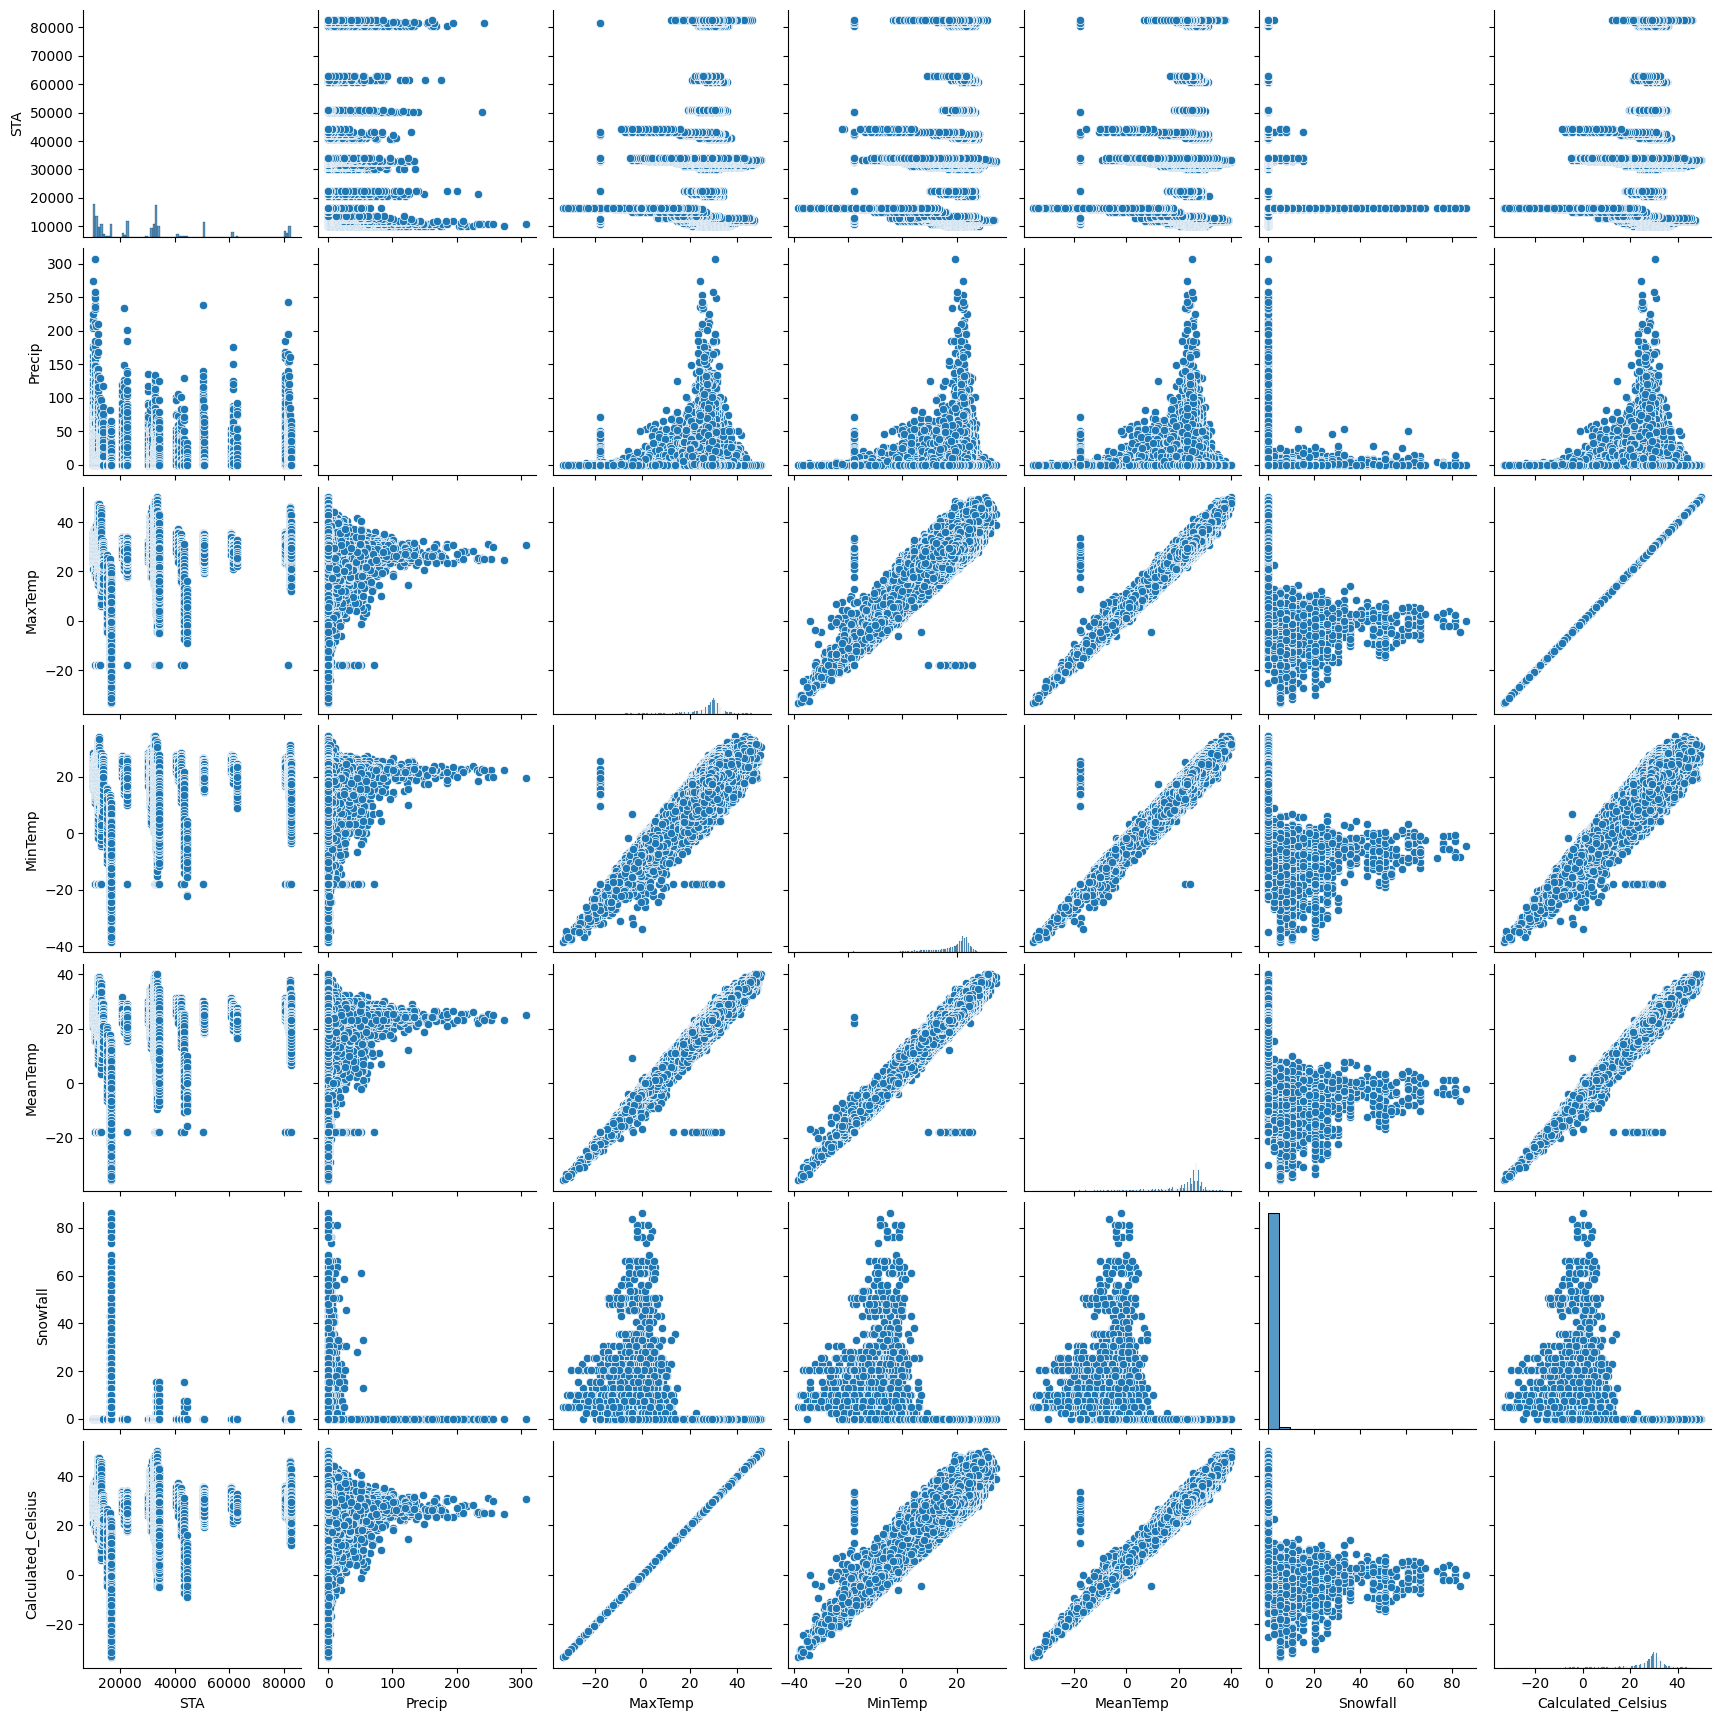

In [26]:
sns.pairplot(df_summary)


In [27]:
df_summary.corr()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,Calculated_Celsius
STA,1.000000,0.119813,0.013386,0.092371,0.059319,0.078112,-0.057715,0.083943
Date,0.119813,1.000000,0.018515,0.047397,-0.003617,0.023279,-0.012258,0.022486
Precip,0.013386,0.018515,1.000000,0.004457,0.088455,0.047061,-0.011043,0.004326
MaxTemp,0.092371,0.047397,0.004457,1.000000,0.878384,0.969048,-0.322013,1.000000
MinTemp,0.059319,-0.003617,0.088455,0.878384,1.000000,0.965425,-0.307854,0.872096
MeanTemp,0.078112,0.023279,0.047061,0.969048,0.965425,1.000000,-0.323671,0.965838
Snowfall,-0.057715,-0.012258,-0.011043,-0.322013,-0.307854,-0.323671,1.000000,-0.340779
Calculated_Celsius,0.083943,0.022486,0.004326,1.000000,0.872096,0.965838,-0.340779,1.000000


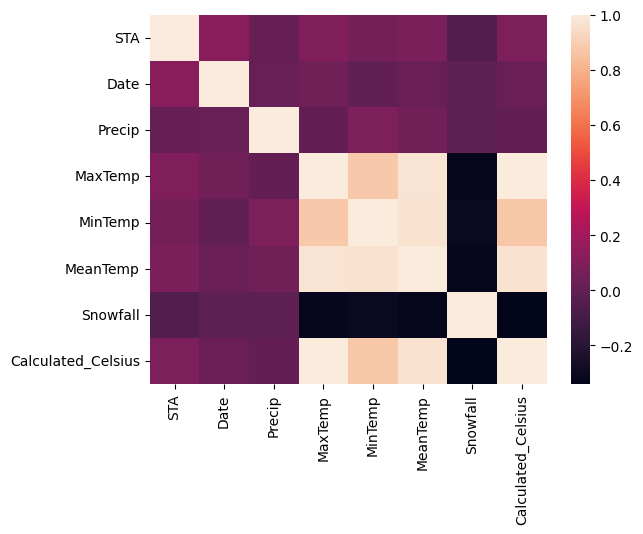

In [28]:
sns.heatmap(df_summary.corr())
plt.show()

In [29]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   WBAN              161 non-null    int64  
 1   NAME              161 non-null    object 
 2   STATE/COUNTRY ID  161 non-null    object 
 3   LAT               161 non-null    object 
 4   LON               161 non-null    object 
 5   ELEV              161 non-null    int64  
 6   Latitude          161 non-null    float64
 7   Longitude         161 non-null    float64
dtypes: float64(2), int64(2), object(4)
memory usage: 10.2+ KB


In [30]:
df_weather.shape

(161, 8)

In [31]:
df_weather.head()

,WBAN,NAME,STATE/COUNTRY ID,LAT,LON,ELEV,Latitude,Longitude
0,33013,AIN EL,AL,3623N,00637E,611,36.383333,6.650000
1,33031,LA SENIA,AL,3537N,00037E,88,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,3643N,00314E,23,36.716667,3.216667
3,33044,TELERGMA,AL,3607N,00621E,754,36.116667,6.416667
4,12001,TINDOUF,AL,2741N,00809W,443,27.683333,-8.083333


In [32]:
df_weather.isnull().sum()

WBAN                0
NAME                0
STATE/COUNTRY ID    0
LAT                 0
LON                 0
ELEV                0
Latitude            0
Longitude           0
dtype: int64

In [33]:
df_weather["LAT"].unique()

array(['3623N', '3537N', '3643N', '3607N', '2741N', '1707N', '2736S',
       '2735S', '2726S', '2625S', '2041S', '1036S', '2327S', '2110S',
       '2324S', '3846N', '2331N', '3222N', '2616N', '1304N', '0352N',
       '0350S', '0346S', '0554S', '0807S', '0235S', '0123S', '0931N',
       '0954N', '0246S', '2124N', '2253N', '1829N', '1252N', '2542N',
       '3127N', '3008N', '0212S', '2521N', '1517N', '1745S', '4233N',
       '4242N', '4155N', '4326N', '4200N', '4844N', '4234N', '0536N',
       '6111N', '6041N', '6701N', '3758N', '1435N', '1355N', '0630N',
       '1833N', '2154N', '2120N', '1943N', '2135N', '2109N', '2129N',
       '6540N', '6358N', '6408N', '2710N', '2526N', '1257N', '2246N',
       '2643N', '2227N', '2445N', '2220N', '2729N', '3322N', '3256N',
       '3022N', '3543N', '3451N', '4133N', '4143N', '4108N', '3915N',
       '4148N', '3918N', '4346N', '4126N', '4127N', '3727N', '4014N',
       '4054N', '3807N', '4341N', '1754N', '4248N', '2621N', '3122N',
       '2612N', '344

In [34]:
df_weather["LON"].unique()

array(['00637E', '00037E', '00314E', '00621E', '00809W', '06147W',
       '15243E', '15301E', '15305E', '14616E', '14030E', '14218E',
       '14408E', '14910E', '15030E', '02706W', '07547W', '06441W',
       '05038E', '05930W', '05149W', '03225W', '03833W', '03515W',
       '03455W', '04414W', '04829W', '08420W', '08408W', '17143W',
       '07755W', '08230W', '06954W', '04458E', '03242E', '02712E',
       '03124E', '08100W', '05524E', '03855E', '17725E', '00929E',
       '00927E', '00848E', '00513E', '00924E', '00222E', '00010W',
       '04525W', '04632W', '05048W', '02343E', '09032W', '09050W',
       '05815W', '07221W', '15935W', '15757W', '15504W', '15812W',
       '15706W', '15802W', '01805W', '02236W', '02157W', '07802E',
       '08150E', '07738E', '08822E', '09248E', '08642E', '08457E',
       '07303E', '09410E', '08713E', '09501E', '04334E', '03944E',
       '04814E', '05123E', '04832E', '01543E', '01522E', '01647E',
       '00905E', '01236E', '00910E', '01115E', '01532E', '0153

In [35]:
df_weather = df_weather.drop(columns=['LAT', 'LON'])

In [36]:
df_final = pd.merge(df_summary, df_weather, left_on='STA', right_on='WBAN', how='inner')

In [37]:
df_final = df_final.drop(columns=['WBAN'])

In [38]:
df_final.head()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,Calculated_Celsius,NAME,STATE/COUNTRY ID,ELEV,Latitude,Longitude
0,10001,1942-07-01,1.016,25.555556,22.222222,23.888889,0.0,25.555556,ACCRA,GH,62,5.6,-0.3
1,10001,1942-07-02,0.000,28.888889,21.666667,25.555556,0.0,28.888889,ACCRA,GH,62,5.6,-0.3
2,10001,1942-07-03,2.540,26.111111,22.222222,24.444444,0.0,26.111111,ACCRA,GH,62,5.6,-0.3
3,10001,1942-07-04,2.540,26.666667,22.222222,24.444444,0.0,26.666667,ACCRA,GH,62,5.6,-0.3
4,10001,1942-07-05,0.000,26.666667,21.666667,24.444444,0.0,26.666667,ACCRA,GH,62,5.6,-0.3


In [39]:
X = df_final[['MinTemp']]
y = df_final['MaxTemp']

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)
print("Coefficient: ", linear.coef_)
print("Intercept: ", linear.intercept_)

Coefficient:  [7.66772356]
Intercept:  27.02093017286081


Mean absolute error 3.1774831170330673
Mean squared error 17.115310788096252
R2 score 0.7721546572113718
Adjusted R2 score: 0.7721450862904784


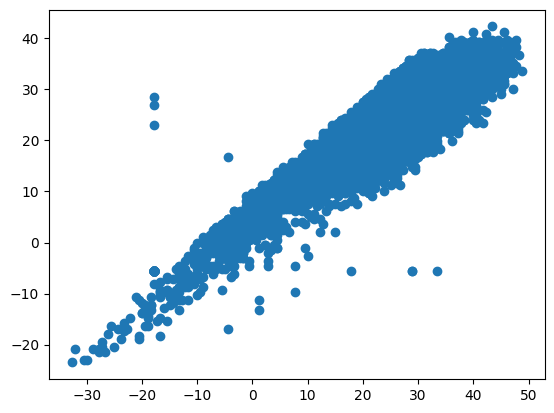

In [44]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
adjusted_r2_score = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("Mean absolute error", mae)
print("Mean squared error", mse)
print("R2 score", r2)
print("Adjusted R2 score:", adjusted_r2_score)
plt.scatter(y_test, y_pred)
plt.show()